In [1]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [2]:
df_env = pl.read_csv(
    "../env_corr/taxon_countries.tsv", separator="\t", infer_schema_length=int(1e4)
)
df_env.head()

taxon_oid,Ecosystem Subtype,Latitude,Longitude,Origin,Isolation Country,Ecosystem Subtype Custom,Plasmid Count,soil_class,bdod (cg/cm³),cec (mmol(c)/kg),cfvo (cm³/dm³),clay (g/kg),nitrogen (cg/kg),ocd (dg/dm³),phh2o (pH*10),sand (g/kg),silt (g/kg),soc (dg/kg),geometry,index_right,ECO_NAME,WWF_REALM,RealmMHT,WWF_REALM2,WWF_MHTNUM,WWF_MHTNAM
str,str,f64,f64,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,str,str,str,str,f64,str
"""3300049023""","""Grasslands""",38.53,-121.78,"""Meta""","""USA""","""Grasslands""",36,"""Luvisols""",152,252,4,267,395,332,69,171,562,335,"""POINT (-121.78…",761.0,"""Great Central …","""NA""","""NA12""","""Nearctic""",12.0,"""Mediterranean …"
"""3300012840""","""Grasslands""",43.07,-89.4,"""Meta""","""USA""","""Grasslands""",21,"""Luvisols""",null,null,null,null,null,null,null,null,null,null,"""POINT (-89.4 4…",187.0,"""Prairie-Forest…","""NA""","""NA4""","""Nearctic""",4.0,"""Temperate Broa…"
"""3300039503""","""Unclassified""",63.88,-149.23,"""Meta""","""USA""","""Unclassified""",3,"""Cambisols""",60,541,112,137,1084,670,49,367,496,2409,"""POINT (-149.23…",734.0,"""Alaska Range""","""NA""","""NA6""","""Nearctic""",6.0,"""Boreal Forests…"
"""3300042005""","""Rhizosphere""",41.2,-97.94,"""Meta""","""USA""","""Rhizosphere""",6,"""Kastanozems""",135,182,3,163,299,377,63,594,242,301,"""POINT (-97.94 …",747.0,"""Central Mixed-…","""NA""","""NA8""","""Nearctic""",8.0,"""Temperate Gras…"
"""3300049265""","""Agricultural l…",38.55,-121.87,"""Meta""","""USA""","""Agricultural l…",1,"""Vertisols""",158,235,8,297,253,330,69,195,508,274,"""POINT (-121.87…",761.0,"""Great Central …","""NA""","""NA12""","""Nearctic""",12.0,"""Mediterranean …"


In [3]:
# df_lengths = pl.read_csv("../ptu_derep/derep_plasmids_lengths.tsv", separator="\t")
# df_lengths = df_lengths.with_columns(
#     pl.col("Plasmid").map_elements(lambda x: x.split("|")[0] if "IMGPR" in x else x)
# )
# df_lengths.head()

In [4]:
with duckdb.connect("../soil_plasmid.db") as con:
    df_potus = con.sql(
        'SELECT pOTU,Members,"Ecosystem Subtype" as potu_ecosystem_subtype, "Ecosystem Subtype Custom" as potu_ecosystem_subtype_custom FROM ptu_derep'
    ).pl()

df_potus = df_potus.with_columns(pl.col("Members").str.split(","), pl.col('Members').str.split(',').list.len().alias('pOTU_length')).explode("Members")
df_potus.head()

pOTU,Members,potu_ecosystem_subtype,potu_ecosystem_subtype_custom,pOTU_length
str,str,str,str,u32
"""pOTU-00000""","""3300056587|Ga0…","""Peat;Grassland…","""Peat;Grassland…",187
"""pOTU-00000""","""3300041809|Ga0…","""Peat;Grassland…","""Peat;Grassland…",187
"""pOTU-00000""","""3300056587|Ga0…","""Peat;Grassland…","""Peat;Grassland…",187
"""pOTU-00000""","""3300055278|Ga0…","""Peat;Grassland…","""Peat;Grassland…",187
"""pOTU-00000""","""3300056587|Ga0…","""Peat;Grassland…","""Peat;Grassland…",187


In [5]:
# potu_envs = dict(df_potus.select(['pOTU', 'Ecosystem Subtype Custom']).with_columns(
#     pl.col('Ecosystem Subtype Custom').str.split(';').map_elements(set)).iter_rows())


In [6]:
# df_potus = df_potus.with_columns(pl.col("Members").str.split(",")).explode("Members").select(["pOTU", "Members"])

# df_potus.head()

In [7]:
df = pl.read_csv(
    "coverm_results.tsv", separator="\t", dtypes={"IMG_Genome_ID": pl.Utf8}, infer_schema_length=10000
)
df.head()

IMG_Genome_ID,BioProject,Sample,Contig,Mean,Trimmed Mean,TPM,Covered Bases,Length
str,str,str,str,f64,f64,f64,i64,i64
"""3300039463""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584
"""3300039426""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584
"""3300039461""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584
"""3300039427""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584
"""3300039460""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584


In [8]:
# sns.histplot(df.filter(pl.col('metag_taxon_oid')==pl.col('plasmid_taxon_oid')).unique(subset='Contig').to_pandas(), x='Coverage', bins=50)

In [9]:
df = (
    df.with_columns(
        pl.col("Contig")
        .map_elements(lambda x: x.split("|")[0])
        .alias("plasmid_taxon_oid"),
        (pl.col('Covered Bases') / pl.col('Length')).alias('Coverage')
    )
    .join(
        df_env.select("taxon_oid", "Ecosystem Subtype", "Ecosystem Subtype Custom"),
        left_on="IMG_Genome_ID",
        right_on="taxon_oid",
        how="left",
    )
    .rename(
        {
            "IMG_Genome_ID": "metag_taxon_oid",
            "Ecosystem Subtype": "metag_ecosystem_subtype",
            "Ecosystem Subtype Custom": "metag_ecosystem_subtype_custom",
        }
    )
    .join(
        df_env.select("taxon_oid", "Ecosystem Subtype", "Ecosystem Subtype Custom"),
        left_on="plasmid_taxon_oid",
        right_on="taxon_oid",
        how="left",
    )
    .join(df_potus, left_on="Contig", right_on="Members")
    .rename(
        {
            "Ecosystem Subtype": "plasmid_ecosystem_subtype",
            "Ecosystem Subtype Custom": "plasmid_ecosystem_subtype_custom",
        }
    )
    
)

df.head()

metag_taxon_oid,BioProject,Sample,Contig,Mean,Trimmed Mean,TPM,Covered Bases,Length,plasmid_taxon_oid,Coverage,metag_ecosystem_subtype,metag_ecosystem_subtype_custom,plasmid_ecosystem_subtype,plasmid_ecosystem_subtype_custom,pOTU,potu_ecosystem_subtype,potu_ecosystem_subtype_custom,pOTU_length
str,str,str,str,f64,f64,f64,i64,i64,str,f64,str,str,str,str,str,str,str,u32
"""3300039463""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584,"""2088090014""",0.0,"""Grasslands""","""Grasslands""","""Grasslands""","""Grasslands""","""pOTU-57264""","""Grasslands""","""Grasslands""",1
"""3300039426""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584,"""2088090014""",0.0,"""Grasslands""","""Grasslands""","""Grasslands""","""Grasslands""","""pOTU-57264""","""Grasslands""","""Grasslands""",1
"""3300039461""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584,"""2088090014""",0.0,"""Grasslands""","""Grasslands""","""Grasslands""","""Grasslands""","""pOTU-57264""","""Grasslands""","""Grasslands""",1
"""3300039427""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584,"""2088090014""",0.0,"""Grasslands""","""Grasslands""","""Grasslands""","""Grasslands""","""pOTU-57264""","""Grasslands""","""Grasslands""",1
"""3300039460""","""PRJEB10725""","""ERR1039458""","""2088090014|GPI…",0.0,0.0,0.0,0,5584,"""2088090014""",0.0,"""Grasslands""","""Grasslands""","""Grasslands""","""Grasslands""","""pOTU-57264""","""Grasslands""","""Grasslands""",1


In [10]:
with open('../plasmids_with_viral_functions.txt') as f:
    viral_functions_plasmids = set(f.read().splitlines())

# df.filter((pl.col("Contig").is_in(viral_functions_plasmids)) & (pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid'))).select(['metag_taxon_oid', 'Contig']).write_csv(
#     'plasmids_with_viral_functions_check.tsv', separator="\t"
# )

a = df.filter((pl.col("Contig").is_in(viral_functions_plasmids)) & (pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid')))
a

metag_taxon_oid,BioProject,Sample,Contig,Mean,Trimmed Mean,TPM,Covered Bases,Length,plasmid_taxon_oid,Coverage,metag_ecosystem_subtype,metag_ecosystem_subtype_custom,plasmid_ecosystem_subtype,plasmid_ecosystem_subtype_custom,pOTU,potu_ecosystem_subtype,potu_ecosystem_subtype_custom,pOTU_length
str,str,str,str,f64,f64,f64,i64,i64,str,f64,str,str,str,str,str,str,str,u32
"""3300039487""","""PRJEB42019""","""ERR5005190""","""3300039487|Ga0…",0.0,0.0,0.0,0,7020,"""3300039487""",0.0,"""Unclassified""","""Unclassified""","""Unclassified""","""Unclassified""","""pOTU-05313""","""Unclassified;U…","""Unclassified;U…",3
"""3300036857""","""PRJNA620814""","""SRR11613032""","""3300036857|Ga0…",10.794848,10.356187,34.308447,10942,10942,"""3300036857""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-05023""","""Agricultural l…","""Agricultural l…",3
"""3300036857""","""PRJNA620814""","""SRR11613032""","""3300036857|Ga0…",13.623315,12.619716,79.915269,6009,6009,"""3300036857""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-09050""","""Agricultural l…","""Agricultural l…",2
"""3300037153""","""PRJNA620815""","""SRR11613357""","""3300037153|Ga0…",26.277082,26.083696,148.229665,24363,24363,"""3300037153""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-19308""","""Agricultural l…","""Agricultural l…",1
"""3300037153""","""PRJNA620815""","""SRR11613357""","""3300037153|Ga0…",30.55468,27.215607,113.312992,57419,57419,"""3300037153""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-05023""","""Agricultural l…","""Agricultural l…",3
"""3300037153""","""PRJNA620815""","""SRR11613357""","""3300037153|Ga0…",23.13288,16.493261,126.329396,19521,19521,"""3300037153""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-19398""","""Agricultural l…","""Agricultural l…",1
"""3300037153""","""PRJNA620815""","""SRR11613357""","""3300037153|Ga0…",14.342335,12.758769,48.45544,10222,10222,"""3300037153""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-09050""","""Agricultural l…","""Agricultural l…",2
"""3300036835""","""PRJNA620817""","""SRR11613358""","""3300036835|Ga0…",36.87335,32.613377,217.599227,23758,23758,"""3300036835""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-20428""","""Agricultural l…","""Agricultural l…",1
"""3300036835""","""PRJNA620817""","""SRR11613358""","""3300036835|Ga0…",31.671469,29.857674,105.654683,31243,31243,"""3300036835""",1.0,"""Agricultural l…","""Agricultural l…","""Agricultural l…","""Agricultural l…","""pOTU-20727""","""Agricultural l…","""Agricultural l…",1


<Axes: xlabel='Trimmed Mean', ylabel='Count'>

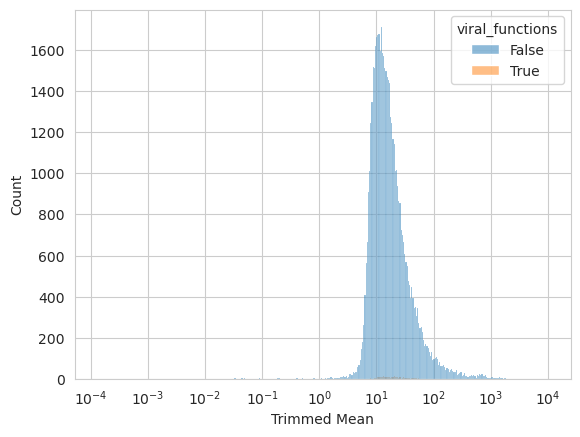

In [11]:
c = df.filter((pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid'))).group_by('Contig').agg(pl.col('Coverage').mean(), pl.col('Trimmed Mean').mean()).with_columns(viral_functions= pl.col('Contig').is_in(viral_functions_plasmids))

sns.histplot(c.to_pandas(), x='Trimmed Mean', hue='viral_functions', log_scale=True)

<Axes: xlabel='Trimmed Mean', ylabel='Count'>

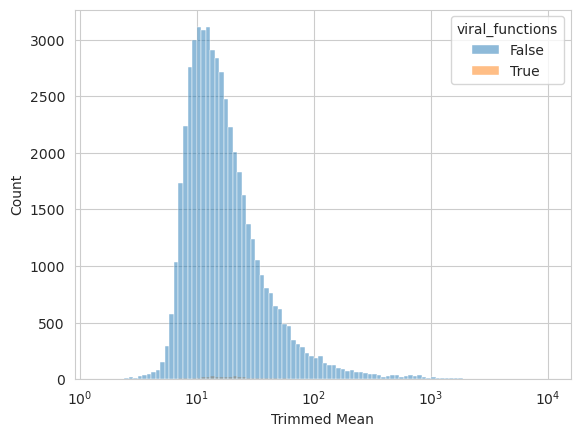

In [21]:
b = df.filter((pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid')) & (pl.col('Coverage')>0.9)).with_columns(viral_functions=pl.col('Contig').is_in(viral_functions_plasmids))

sns.histplot(b.to_pandas(), x='Trimmed Mean', hue='viral_functions', bins=100, log_scale=True)

<Axes: xlabel='Trimmed Mean', ylabel='Count'>

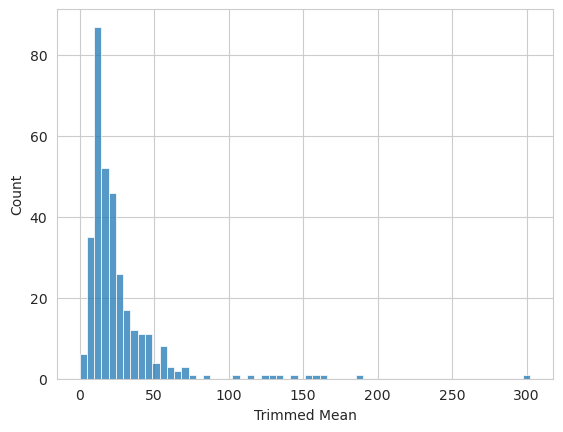

In [14]:
sns.histplot(a.to_pandas(), x='Trimmed Mean')

<Axes: xlabel='Coverage', ylabel='Count'>

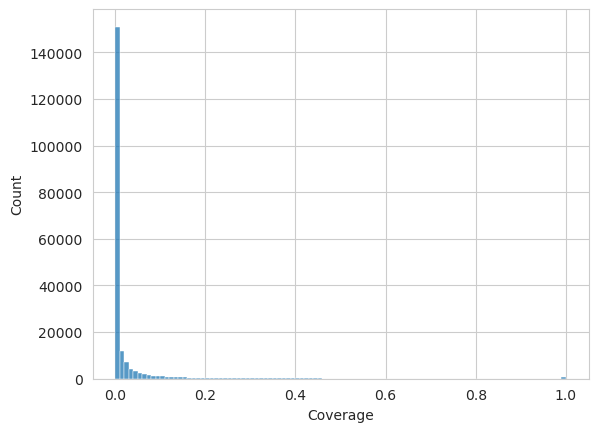

In [10]:
sns.histplot(df.sample(200_000).to_pandas(), x="Coverage", bins=100)

<Axes: ylabel='Length'>

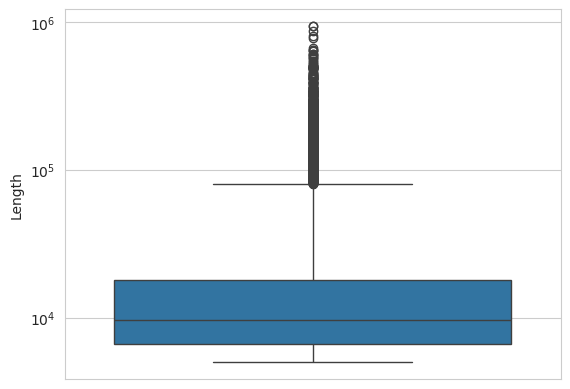

In [11]:
#Plasmid coverage on the samples they were assembled

sns.boxplot(df.filter((pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid')) & (pl.col('Coverage') == 1)).unique(subset=['Sample','Contig']).to_pandas(), y='Length', log_scale=True)

In [12]:
df.filter((pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid'))).group_by('Contig').agg(pl.col('Coverage').max()).filter(pl.col('Coverage') < 1)

Contig,Coverage
str,f64
"""3300056815|Ga0…",0.998175
"""3300041809|Ga0…",0.0
"""3300010367|Ga0…",0.059466
"""3300010375|Ga0…",0.999251
"""3300041809|Ga0…",0.0
"""3300020886|Ga0…",0.998203
"""3300048091|Ga0…",0.0
"""3300012893|Ga0…",0.999387
"""3300035490|Ga0…",0.631883


<Axes: xlabel='Coverage', ylabel='Count'>

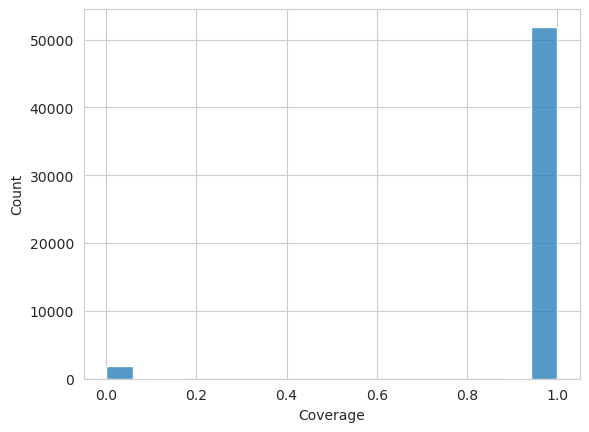

In [13]:
sns.histplot(df.filter((pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid'))).group_by('Contig').agg(pl.col('Coverage').max()), x='Coverage')

<Axes: xlabel='Length', ylabel='Count'>

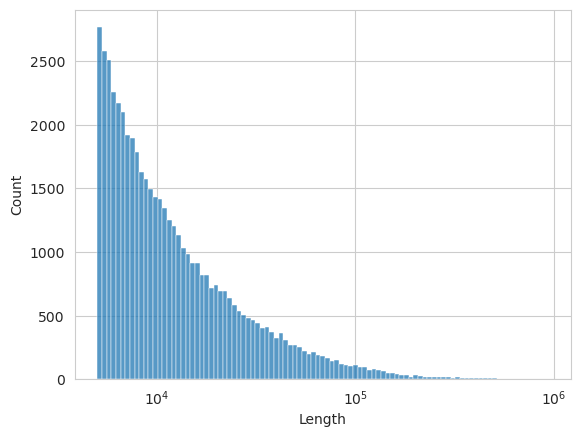

In [14]:
#Plasmid coverage on the samples they were assembled

sns.histplot(df.filter((pl.col('metag_taxon_oid') == pl.col('plasmid_taxon_oid')) & (pl.col('Coverage') == 1)).unique(subset=['Sample','Contig']).to_pandas(), x='Length', log_scale=True)

In [15]:

# #Old way
# df_new_env_potu_num = (
#     df.filter(
#         (pl.col("Coverage") >= 0.7) & (pl.col('Trimmed Mean')>=1) & (pl.col('metag_taxon_oid') != pl.col('plasmid_taxon_oid'))
#         & (~
#             pl.col("metag_ecosystem_subtype_custom").is_in(
#                 pl.col("potu_ecosystem_subtype_custom").str.split(";")
#             )
#         )
#     ).unique(subset=["pOTU", 'Sample', 'metag_ecosystem_subtype_custom']).group_by("metag_ecosystem_subtype_custom").agg(pl.col("pOTU").n_unique())
# )

# df_new_env_potu_num

KeyboardInterrupt: 

In [ ]:

# #Mixed way

# df_new_env_potu_num = df.filter(
#         (pl.col("Covered Bases") >= pl.col("Length") * 0.7) & (pl.col('Trimmed Mean')>=1) & (pl.col('metag_taxon_oid') != pl.col('plasmid_taxon_oid'))
#         & (~
#             pl.col("metag_ecosystem_subtype_custom").is_in(
#                 pl.col("potu_ecosystem_subtype_custom").str.split(";")
#             )
#         )
#     ).unique(subset=["pOTU", 'Sample', 'metag_ecosystem_subtype_custom']).group_by(["metag_ecosystem_subtype_custom", 'pOTU']).agg(pl.col("pOTU_length").first()).filter(pl.col("pOTU_length") > 1).group_by("metag_ecosystem_subtype_custom").agg(pl.col("pOTU").n_unique())

# df_new_env_potu_num

metag_ecosystem_subtype_custom,pOTU
str,u32
"""Rhizosphere""",1534
"""Grasslands""",1600
"""Agricultural l…",1499
"""Other""",2044
"""Unclassified""",1815
"""Temperate fore…",1254
"""Peat""",447
"""Tropical fores…",702


In [ ]:
# results = []

# base_df = df.filter((~
#             pl.col("metag_ecosystem_subtype_custom").is_in(
#                 pl.col("potu_ecosystem_subtype_custom").str.split(";")
#             )))
# for i in np.arange(0.1,1.1,0.1):
#     a = base_df.filter(
#         ((pl.col('Trimmed Mean')>=1) & (pl.col('metag_taxon_oid') != pl.col('plasmid_taxon_oid'))) & (pl.col("Covered Bases") >= pl.col("Length") * i)
#         ).unique(subset=['Contig', 'Sample', 'metag_ecosystem_subtype_custom']).group_by(['metag_ecosystem_subtype_custom', 'Contig']).agg(pl.col('Coverage').max(), pl.col('Length').mean()).join(df_potus.select(['pOTU', 'Members', 'pOTU_length']), left_on='Contig', right_on='Members', how='left').group_by(['metag_ecosystem_subtype_custom', 'pOTU']).agg(pl.col('Coverage').alias('Member_coverages'), pl.col('pOTU_length').first(), pl.col('Length').mean())

#     #add column with the i value
#     a = a.with_columns(pl.lit(str(i)).alias('Coverage_threshold'))
#     results.append(a)



/tmp/ipykernel_1424302/4046229169.py:1: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.boxplot(pl.concat(results).to_pandas(), y="Length", log_scale=True, x="Coverage_threshold").set_xticklabels(["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]);


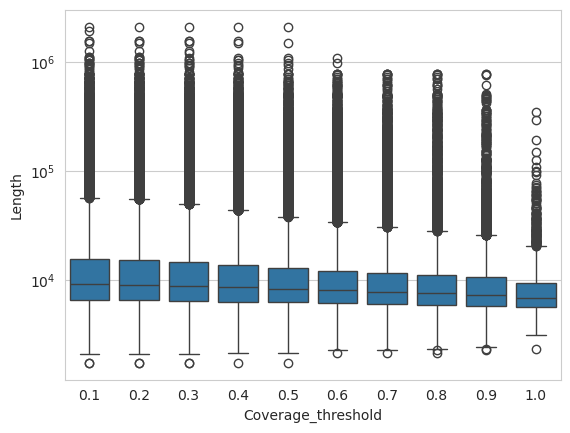

In [ ]:
# sns.boxplot(pl.concat(results).to_pandas(), y="Length", log_scale=True, x="Coverage_threshold").set_xticklabels(["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]);

In [ ]:
# Consider pOTUs where the trimmed mean is at least 1 and the plasmid is from another taxon_oid. Then, consider rows where the metagenome is not in the pOTU's ecosystem list.
# Then remove duplications where the Sample (run), Contig (plasmid), and metagenome ecosystem subtype are repeated.
# Group by metagenome ecosystem and plasmid. Take the maximum coverage for each plasmid (it can be well covered in one sample and not in another).
# Then get back the pOTU information for each plasmid, and group by metagenome ecosystem and pOTU, taking all the max coverages for the pOTU members.
# Finally, filter for pOTUs that have at least 50% of their members covered by at least 70% in the metagenome ecosystem.



df_new_env_potu_num_nsingl = df.filter(
        ((pl.col('Trimmed Mean')>=1) & (pl.col('metag_taxon_oid') != pl.col('plasmid_taxon_oid')))
        & (~
            pl.col("metag_ecosystem_subtype_custom").is_in(
                pl.col("potu_ecosystem_subtype_custom").str.split(";")
            )
        )).unique(subset=['Contig', 'Sample', 'metag_ecosystem_subtype_custom']).group_by(['metag_ecosystem_subtype_custom', 'Contig']).agg(pl.col('Coverage').max()).join(df_potus.select(['pOTU', 'Members', 'pOTU_length']), left_on='Contig', right_on='Members', how='left').group_by(['metag_ecosystem_subtype_custom', 'pOTU']).agg(pl.col('Coverage').alias('Member_coverages'), pl.col('pOTU_length').first()).with_columns(pl.col('Member_coverages').list.eval(pl.element() >= 0.7).list.sum().alias('n_members_covered')).filter((pl.col('pOTU_length') > 1) & (pl.col('n_members_covered') >=  pl.col('pOTU_length') * 0.5)).group_by('metag_ecosystem_subtype_custom').agg(pl.col('pOTU').n_unique())
        

df_new_env_potu_num_nsingl

metag_ecosystem_subtype_custom,pOTU
str,u32
"""Other""",1615
"""Peat""",306
"""Temperate fore…",1011
"""Rhizosphere""",1211
"""Agricultural l…",1187
"""Unclassified""",1364
"""Tropical fores…",495
"""Grasslands""",1210


In [ ]:
df_new_env_potu_num_wsingl = df.filter(
        ((pl.col('Coverage')>=0.7) & (pl.col('Trimmed Mean')>=1) & (pl.col('metag_taxon_oid') != pl.col('plasmid_taxon_oid')))
        & (~
            pl.col("metag_ecosystem_subtype_custom").is_in(
                pl.col("potu_ecosystem_subtype_custom").str.split(";")
            )
        )).unique(subset=['Contig', 'Sample', 'metag_ecosystem_subtype_custom']).group_by(['metag_ecosystem_subtype_custom', 'Contig']).agg(pl.col('Coverage').max()).join(df_potus.select(['pOTU', 'Members', 'pOTU_length']), left_on='Contig', right_on='Members', how='left').group_by('metag_ecosystem_subtype_custom').agg(pl.col('pOTU').n_unique())
        
df_new_env_potu_num_wsingl

In [ ]:
final_df = df_potus.with_columns(pl.col("potu_ecosystem_subtype_custom").str.split(";")).explode(
    "potu_ecosystem_subtype_custom"
).group_by("potu_ecosystem_subtype_custom").agg(pl.col("pOTU").n_unique()).join(
    df_new_env_potu_num_wsingl,
    left_on="potu_ecosystem_subtype_custom",
    right_on="metag_ecosystem_subtype_custom",
    how="left",
).rename(
    {
        "pOTU": "original_pOTU_count",
        "pOTU_right": "additional_pOTU",
        "potu_ecosystem_subtype_custom": "Ecosystem",
    }
).fill_null(0).with_columns(
    percentage_increase=pl.col("additional_pOTU") / (pl.col("original_pOTU_count")) * 100
)
final_df

Ecosystem,original_pOTU_count,additional_pOTU,percentage_increase
str,u32,u32,f64
"""Peat""",7565,1324,17.501652
"""Other""",5750,4475,77.826087
"""Temperate fore…",12301,3402,27.656288
"""Unclassified""",11705,3657,31.243059
"""Tropical fores…",1242,1418,114.170692
"""Grasslands""",4986,3192,64.019254
"""Rhizosphere""",13458,3786,28.131966
"""Agricultural l…",6404,3351,52.326671


In [ ]:
final_df = final_df.join(
    df_new_env_potu_num_nsingl,
    left_on="Ecosystem",
    right_on="metag_ecosystem_subtype_custom",
    how="left",
).rename(
    {
        "pOTU": "additional_pOTU_nsingl",
    }
).fill_null(0).with_columns(
    percentage_increase_nsingl=pl.col("additional_pOTU_nsingl") / (pl.col("original_pOTU_count")) * 100
)
final_df

Ecosystem,original_pOTU_count,additional_pOTU,percentage_increase,additional_pOTU_nsingl,percentage_increase_nsingl
str,u32,u32,f64,u32,f64
"""Peat""",7565,1324,17.501652,306,4.044944
"""Other""",5750,4475,77.826087,1615,28.086957
"""Temperate fore…",12301,3402,27.656288,1011,8.218844
"""Unclassified""",11705,3657,31.243059,1364,11.65314
"""Tropical fores…",1242,1418,114.170692,495,39.855072
"""Grasslands""",4986,3192,64.019254,1210,24.26795
"""Rhizosphere""",13458,3786,28.131966,1211,8.998365
"""Agricultural l…",6404,3351,52.326671,1187,18.53529


In [ ]:
final_df.melt(
    id_vars="Ecosystem",
    value_vars=["percentage_increase", "percentage_increase_nsingl"],
).filter(pl.col('variable')=='percentage_increase')

Ecosystem,variable,value
str,str,f64
"""Peat""","""percentage_inc…",17.501652
"""Other""","""percentage_inc…",77.826087
"""Temperate fore…","""percentage_inc…",27.656288
"""Unclassified""","""percentage_inc…",31.243059
"""Tropical fores…","""percentage_inc…",114.170692
"""Grasslands""","""percentage_inc…",64.019254
"""Rhizosphere""","""percentage_inc…",28.131966
"""Agricultural l…","""percentage_inc…",52.326671


In [ ]:
final_df.filter(~pl.col('Ecosystem').is_in(['Unclassified'])).select(pl.col('percentage_increase').median(), pl.col('percentage_increase_nsingl').median())

percentage_increase,percentage_increase_nsingl
f64,f64
52.326671,18.53529


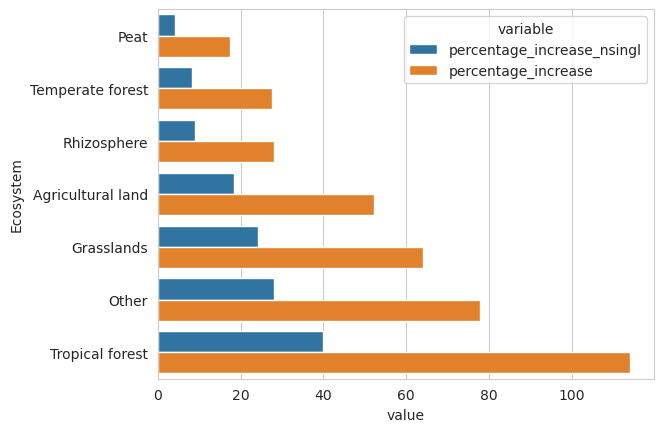

In [ ]:
fig, ax = plt.subplots()

sns.barplot(
    data=final_df.melt(
    id_vars="Ecosystem",
    value_vars=["percentage_increase", "percentage_increase_nsingl"],
).filter(pl.col('Ecosystem')!='Unclassified').sort(by='value').to_pandas(),
    y="Ecosystem",
    x="value",
    hue="variable",
    ax=ax
)

fig.savefig("../figures/new_env_potu_num.pdf", bbox_inches="tight")

## Can we recover isolate plasmids from the metagenomes?

In [ ]:
df.filter(
        (pl.col("Covered Bases") >= pl.col("Length") * 0.7) & (pl.col('Trimmed Mean')>=1)
        & (pl.col('Contig').str.contains('IMGPR|Refsoil|PLSDB'))).unique(subset=['Contig'])

metag_taxon_oid,BioProject,Sample,Contig,Mean,Trimmed Mean,TPM,Covered Bases,Length,plasmid_taxon_oid,Coverage,metag_ecosystem_subtype,metag_ecosystem_subtype_custom,plasmid_ecosystem_subtype,plasmid_ecosystem_subtype_custom,pOTU,potu_ecosystem_subtype,potu_ecosystem_subtype_custom,pOTU_length
str,str,str,str,f64,f64,f64,i64,i64,str,f64,str,str,str,str,str,str,str,u32
"""3300047323""","""PRJNA1016790""","""SRR26075501""","""IMGPR_plasmid_…",8.841157,8.497314,65.829983,81835,87028,"""IMGPR_plasmid_…",0.94033,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-01382""","""Unclassified;U…","""Unclassified;U…",7
"""3300009036""","""PRJNA405460""","""SRR6056515""","""IMGPR_plasmid_…",3.5582933,3.2470438,6.008164,17004,21010,"""IMGPR_plasmid_…",0.809329,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-00172""","""Unclassified;U…","""Unclassified;U…",20
"""3300009036""","""PRJNA405460""","""SRR6056515""","""IMGPR_plasmid_…",11.812679,11.57439,20.160127,19436,19977,"""IMGPR_plasmid_…",0.972919,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-01644""","""Unclassified;U…","""Unclassified;U…",6
"""3300009036""","""PRJNA405460""","""SRR6056515""","""IMGPR_plasmid_…",6.8636484,6.1015706,28.307777,10979,11679,"""IMGPR_plasmid_…",0.940063,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-06228""","""Unclassified;U…","""Unclassified;U…",3
"""3300046455""","""PRJNA1016742""","""SRR26077552""","""IMGPR_plasmid_…",15.44347,12.208514,402.654201,63659,78683,"""IMGPR_plasmid_…",0.809057,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-01973""","""Unclassified;R…","""Unclassified;R…",5
"""3300002076""","""PRJNA330353""","""SRR3989284""","""IMGPR_plasmid_…",2.3842766,2.1343284,47.646055,3826,4691,"""IMGPR_plasmid_…",0.815604,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-00602""","""Unclassified;U…","""Unclassified;U…",11
"""3300009036""","""PRJNA405460""","""SRR6056515""","""PLSDB_NZ_CP081…",8.564469,7.342059,22.276443,230092,262462,"""PLSDB_NZ_CP081…",0.876668,"""Rhizosphere""","""Rhizosphere""","""Unclassified""","""Unclassified""","""pOTU-02427""","""Unclassified;U…","""Unclassified;U…",5
"""3300025711""","""PRJNA405466""","""SRR6056553""","""IMGPR_plasmid_…",6.3222446,5.6623473,6.855109,78693,93098,"""IMGPR_plasmid_…",0.845271,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-01623""","""Agricultural l…","""Agricultural l…",6
"""3300025735""","""PRJNA405467""","""SRR6056556""","""IMGPR_plasmid_…",3.2835069,2.8900473,13.748484,30459,34255,"""IMGPR_plasmid_…",0.889184,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-02284""","""Unclassified;U…","""Unclassified;U…",5


In [16]:
df.filter(
        (pl.col("Covered Bases") >= pl.col("Length") * 0.7) & (pl.col('Trimmed Mean')>=1)
        & (pl.col('Contig').str.contains('IMGPR|Refsoil|PLSDB'))).unique(subset=['pOTU'])

metag_taxon_oid,BioProject,Sample,Contig,Mean,Trimmed Mean,TPM,Covered Bases,Length,plasmid_taxon_oid,Coverage,metag_ecosystem_subtype,metag_ecosystem_subtype_custom,plasmid_ecosystem_subtype,plasmid_ecosystem_subtype_custom,pOTU,potu_ecosystem_subtype,potu_ecosystem_subtype_custom,pOTU_length
str,str,str,str,f64,f64,f64,i64,i64,str,f64,str,str,str,str,str,str,str,u32
"""3300009036""","""PRJNA405460""","""SRR6056515""","""IMGPR_plasmid_…",18.712696,14.820285,85.352076,5707,7160,"""IMGPR_plasmid_…",0.797067,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-39376""","""Unclassified""","""Unclassified""",1
"""3300047469""","""PRJNA1016780""","""SRR26075482""","""IMGPR_plasmid_…",7.565401,5.58721,83.319181,8977,9393,"""IMGPR_plasmid_…",0.955712,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-38987""","""Unclassified""","""Unclassified""",1
"""3300009036""","""PRJNA405460""","""SRR6056515""","""IMGPR_plasmid_…",3.4717312,2.6884422,8.113687,8297,9878,"""IMGPR_plasmid_…",0.839947,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-02554""","""Unclassified;U…","""Unclassified;U…",5
"""3300009095""","""PRJNA375195""","""SRR5690606""","""Refsoil_NC_021…",68.87939,43.39976,1431.920216,39355,52268,"""Refsoil_NC_021…",0.752946,"""Agricultural l…","""Agricultural l…","""Unclassified""","""Unclassified""","""pOTU-43286""","""Unclassified""","""Unclassified""",1
"""3300041997""","""PRJNA697409""","""SRR18726760""","""IMGPR_plasmid_…",2.0870667,1.9038147,42.197495,9441,12382,"""IMGPR_plasmid_…",0.762478,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-40258""","""Unclassified""","""Unclassified""",1
"""3300042006""","""PRJNA697410""","""SRR18726762""","""IMGPR_plasmid_…",34.26108,34.06783,656.00581,19467,19527,"""IMGPR_plasmid_…",0.996927,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-39991""","""Unclassified""","""Unclassified""",1
"""3300036802""","""PRJNA620646""","""SRR11835592""","""PLSDB_NZ_CP009…",11.30761,9.603525,18.031413,8784,10361,"""PLSDB_NZ_CP009…",0.847795,"""Temperate fore…","""Temperate fore…","""Unclassified""","""Unclassified""","""pOTU-06159""","""Agricultural l…","""Agricultural l…",3
"""3300009095""","""PRJNA375195""","""SRR5690606""","""PLSDB_NZ_CP016…",53.43207,41.812252,1458.805869,3361,4066,"""PLSDB_NZ_CP016…",0.826611,"""Agricultural l…","""Agricultural l…","""Unclassified""","""Unclassified""","""pOTU-06182""","""Unclassified;U…","""Unclassified;U…",3
"""3300047469""","""PRJNA1016780""","""SRR26075482""","""IMGPR_plasmid_…",2.740634,2.069683,51.201649,170752,224578,"""IMGPR_plasmid_…",0.760324,"""Rhizosphere""","""Rhizosphere""",null,null,"""pOTU-02788""","""Unclassified;U…","""Unclassified;U…",4


In [19]:
with duckdb.connect("../soil_plasmid.db") as con:
    df_potus2 = con.sql(
        'SELECT pOTU,Members,Origin, "Ecosystem Subtype" as potu_ecosystem_subtype, "Ecosystem Subtype Custom" as potu_ecosystem_subtype_custom FROM ptu_derep'
    ).pl()

hit_ptus = df.filter(
        (pl.col("Covered Bases") >= pl.col("Length") * 0.7) & (pl.col('Trimmed Mean')>=1)
        & (pl.col('Contig').str.contains('IMGPR|Refsoil|PLSDB'))).unique(subset=['pOTU']).get_column('pOTU').unique().to_list()

In [26]:
df_potus2.filter(pl.col('pOTU').is_in(hit_ptus)).select(pl.col('Origin').value_counts())

Origin
struct[2]
"{""Both"",278}"
"{""Isolate"",648}"


The above means we are finding 648 pOTUs which were only found in isolates, to be found in metagenomes also by read mapping. If originally we had a 933 pOTU overlap, this would go up to 1581 pOTUs. This is a 69% increase in the number of isolate pOTUs found in metagenomes. If before only 15% of pOTUs were found in metagenomes, now 26% of pOTUs are found in metagenomes (74% of pOTUs are still not found in metagenomes, while before 85% were not found).

### Is 1600 SRA runs enough? Are we saturating pOTU discovery?

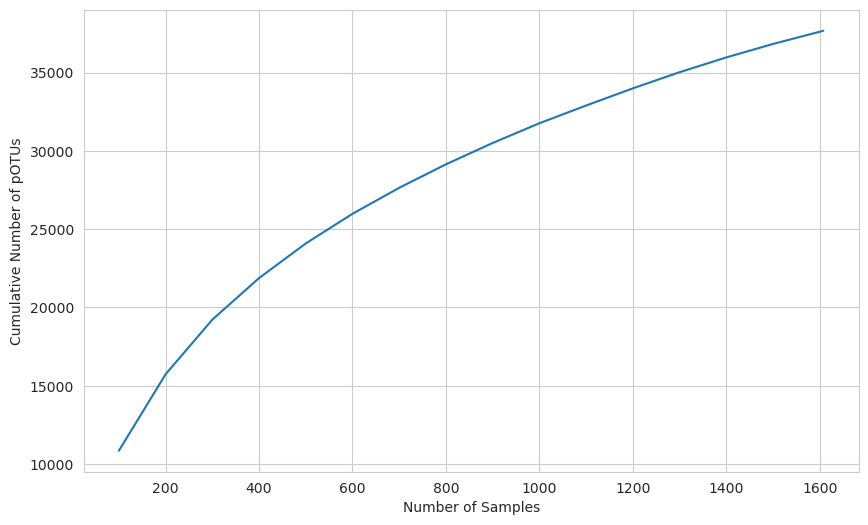

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def create_rarefaction_curve(df, n_iterations=100, step_size=100):
    # Build sample-pOTU mapping efficiently
    sample_potu_dict = defaultdict(set)
    for sample, potu in df.select(['Sample', 'pOTU']).iter_rows():
        if potu is not None:
            sample_potu_dict[sample].add(potu)
    
    samples = np.array(list(sample_potu_dict.keys()))
    n_samples = len(samples)
    sample_points = np.arange(step_size, n_samples + 1, step_size)
    if sample_points[-1] != n_samples:
        sample_points = np.append(sample_points, n_samples)

    results = np.zeros((n_iterations, len(sample_points)), dtype=int)

    sample_potu_list = [sample_potu_dict[sample] for sample in samples]
    for i in range(n_iterations):
        shuffled_indices = np.random.permutation(n_samples)
        cumulative_potus = set()
        last_idx = 0
        for j, n_use in enumerate(sample_points):
            # Only add new samples since last step
            for idx in shuffled_indices[last_idx:n_use]:
                cumulative_potus.update(sample_potu_list[idx])
                results[i, j] = len(cumulative_potus)
            last_idx = n_use
        
    mean_counts = results.mean(axis=0)

    return sample_points, mean_counts

sample_df = df.filter(pl.col("Covered Bases") >= pl.col("Length") * 0.8).unique(subset=['Sample', 'pOTU'])
sample_counts, mean_potu_counts= create_rarefaction_curve(sample_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=sample_counts, y=mean_potu_counts)

ax.set_xlabel('Number of Samples');
ax.set_ylabel('Cumulative Number of pOTUs');
